# Exploratory Data Analysis
Ready-To-Train AI4Arctic Sea Ice Challenge Training Dataset

In [4]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import re
from collections import defaultdict
import random
import tempfile
import os
from io import BytesIO

## Load the Data

In [3]:
data = xr.open_dataset("../20180124T194759_dmi_prep.nc")
print(data)
print(list(data.data_vars))
print(data.dims)

<xarray.Dataset> Size: 422MB
Dimensions:               (sar_sample_2dgrid_points: 21,
                           sar_line_2dgrid_points: 21, sar_lines: 5003,
                           sar_samples: 5229, 2km_grid_lines: 200,
                           2km_grid_samples: 209)
Dimensions without coordinates: sar_sample_2dgrid_points,
                                sar_line_2dgrid_points, sar_lines, sar_samples,
                                2km_grid_lines, 2km_grid_samples
Data variables: (12/26)
    sar_grid2d_latitude   (sar_sample_2dgrid_points, sar_line_2dgrid_points) float64 4kB ...
    sar_grid2d_longitude  (sar_sample_2dgrid_points, sar_line_2dgrid_points) float64 4kB ...
    nersc_sar_primary     (sar_lines, sar_samples) float32 105MB ...
    nersc_sar_secondary   (sar_lines, sar_samples) float32 105MB ...
    sar_incidenceangle    (sar_lines, sar_samples) float32 105MB ...
    distance_map          (sar_lines, sar_samples) float32 105MB ...
    ...                    ...
    u

In [4]:
rows = []
for v in data.data_vars:
    arr = data[v].values
    flat = arr.flatten().astype(float)
    valid = flat[~np.isnan(flat) & (flat != 255)]
    rows.append({
        'variable': v,
        'shape': str(arr.shape),
        'dtype': arr.dtype,
        'mean': np.mean(valid),
        'std': np.std(valid),
        'min': round(float(valid.min()),3) if len(valid) else None,
        'max': round(float(valid.max()),3) if len(valid) else None,
    })
display(pd.DataFrame(rows))

,variable,shape,dtype,mean,std,min,max
0,sar_grid2d_latitude,"(21, 21)",float64,64.703523,1.102691,62.497,66.858
1,sar_grid2d_longitude,"(21, 21)",float64,-35.204997,2.660750,-40.704,-30.235
2,nersc_sar_primary,"(5003, 5229)",float32,-0.182812,0.723336,-9.390,4.624
3,nersc_sar_secondary,"(5003, 5229)",float32,-0.170679,0.466425,-6.158,8.201
4,sar_incidenceangle,"(5003, 5229)",float32,-0.017622,0.620421,-1.741,1.510
5,distance_map,"(5003, 5229)",float32,0.361372,0.838014,-1.576,1.159
6,btemp_6_9h,"(200, 209)",float32,-0.497739,0.854682,-1.131,1.387
7,btemp_6_9v,"(200, 209)",float32,-0.491262,0.833402,-1.149,1.297
8,btemp_7_3h,"(200, 209)",float32,-0.495255,0.852757,-1.127,1.385
9,btemp_7_3v,"(200, 209)",float32,-0.495220,0.833592,-1.159,1.290


## Comparison to Raw Data
- The values in the RTT dataset are normalized, as seen by the mean values close to zero.
- The SAR grid is downsampled 2x
- polygon_icechart and sar_grid_* vectors dropped
- tcwv and tclw ranges in RTT dataset are all negative

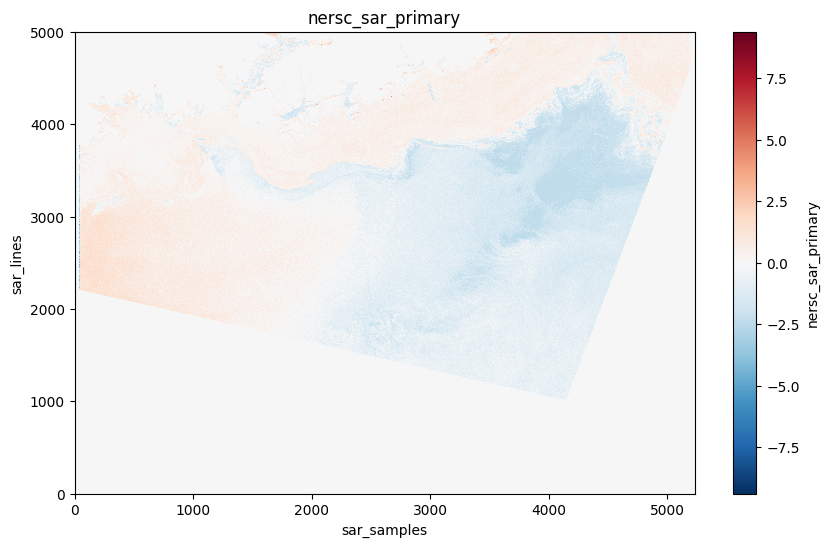

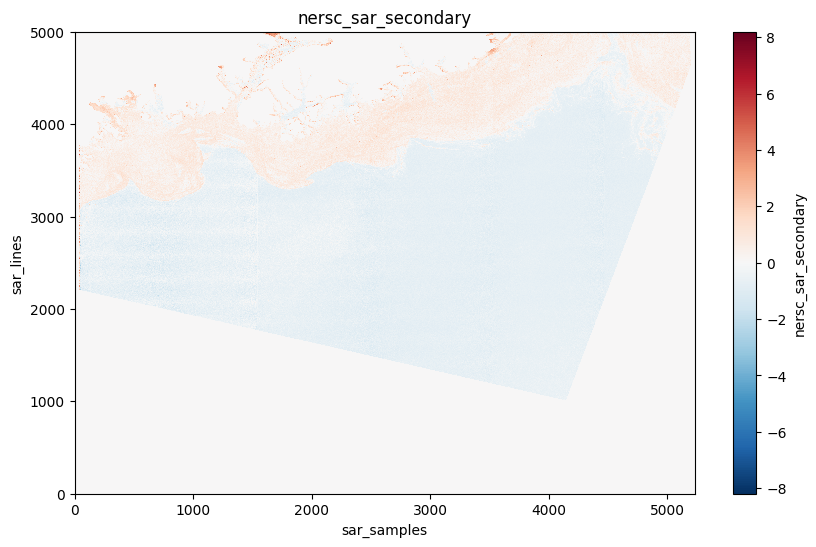

In [5]:
for var in ['nersc_sar_primary', 'nersc_sar_secondary']:
    plt.figure(figsize=(10, 6))
    data[var].plot()
    plt.title(var)
    plt.show()

In [ ]:
import seaborn as sns

# Block-average SAR to the 2km AMSR2 grid — each output pixel is the mean of
# an (rs × cs) patch, making the spatial scale comparable to AMSR2/ERA5.
h, w     = data['nersc_sar_primary'].shape
h_g, w_g = 200, 209
rs, cs   = h // h_g, w // w_g

def block_mean(arr):
    a = arr.astype(float)
    return np.nanmean(a[:h_g*rs, :w_g*cs].reshape(h_g, rs, w_g, cs), axis=(1, 3))

hh = block_mean(data['nersc_sar_primary'].values)
hv = block_mean(data['nersc_sar_secondary'].values)

cols = {
    'SAR HH':   hh.flatten(),
    'SAR HV':   hv.flatten(),
    'HH-HV':    (hh - hv).flatten(),
    'BT 6.9H':  data['btemp_6_9h'].values.flatten(),
    'BT 6.9V':  data['btemp_6_9v'].values.flatten(),
    'BT 10.7H': data['btemp_10_7h'].values.flatten(),
    'BT 10.7V': data['btemp_10_7v'].values.flatten(),
    'BT 18.7H': data['btemp_18_7h'].values.flatten(),
    'BT 18.7V': data['btemp_18_7v'].values.flatten(),
    'BT 36.5H': data['btemp_36_5h'].values.flatten(),
    'BT 36.5V': data['btemp_36_5v'].values.flatten(),
    'BT 89H':   data['btemp_89_0h'].values.flatten(),
    'BT 89V':   data['btemp_89_0v'].values.flatten(),
    'wind_u':   data['u10m_rotated'].values.flatten(),
    'wind_v':   data['v10m_rotated'].values.flatten(),
    'T2m':      data['t2m'].values.flatten(),
    'SKT':      data['skt'].values.flatten(),
    'TCWV':     data['tcwv'].values.flatten(),
    'TCLW':     data['tclw'].values.flatten(),
}

df_corr = pd.DataFrame(cols).replace(255, np.nan).dropna()
corr = df_corr.corr()

fig, ax = plt.subplots(figsize=(16, 13))
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
    square=True, linewidths=0.4, ax=ax, annot_kws={'size': 8},
    vmin=-1, vmax=1,
)
ax.set_title('Feature Correlation Matrix (SAR block-averaged to 2 km grid)', fontsize=14)
plt.tight_layout()
plt.show()

## Incidence Angle vs. Backscatter

SAR backscatter varies with incidence angle independently of surface type — steeper angles (near range) produce higher returns. The RTT dataset provides a full-resolution `sar_incidenceangle` image (interpolated from the raw sparse grid), making it possible to quantify this effect. A non-zero slope here means incidence angle is a confound that the model must account for or that should be corrected in preprocessing.

In [ ]:
# Subsample to 2km grid to keep scatter manageable
h, w     = data['nersc_sar_primary'].shape
h_g, w_g = 200, 209
rs, cs   = h // h_g, w // w_g

ia  = data['sar_incidenceangle'].values[::rs, ::cs][:h_g, :w_g].flatten()
hh  = data['nersc_sar_primary'].values[::rs, ::cs][:h_g, :w_g].flatten()
hv  = data['nersc_sar_secondary'].values[::rs, ::cs][:h_g, :w_g].flatten()

mask = ~(np.isnan(ia) | np.isnan(hh) | np.isnan(hv))
ia, hh, hv = ia[mask], hh[mask], hv[mask]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, arr, label in zip(axes, [hh, hv], ['SAR HH', 'SAR HV']):
    ax.scatter(ia, arr, alpha=0.2, s=5, color='steelblue')
    coeffs = np.polyfit(ia, arr, 1)
    x_fit  = np.linspace(ia.min(), ia.max(), 100)
    ax.plot(x_fit, np.polyval(coeffs, x_fit), 'r-', linewidth=1.5,
            label=f'slope = {coeffs[0]:.3f}')
    r = np.corrcoef(ia, arr)[0, 1]
    ax.set_xlabel('Incidence angle (normalized)')
    ax.set_ylabel(f'{label} (normalized)')
    ax.set_title(f'{label} vs incidence angle  (r = {r:.2f})')
    ax.legend()

plt.suptitle('SAR Backscatter vs Incidence Angle', fontsize=12)
plt.tight_layout()
plt.show()

In [2]:
import boto3
session = boto3.Session(profile_name='spk_data')
s3 = session.client('s3')

In [15]:
bucket = "prescient-ice-data"
prefix = "training_data/ai4arctic/rtt_train/"

result = s3.list_objects(Bucket = bucket, Prefix=prefix, MaxKeys=5)
for o in result.get('Contents', []):
    print(o['Key'])

training_data/ai4arctic/rtt_train/20180108T184332_dmi_prep.nc
training_data/ai4arctic/rtt_train/20180122T205424_dmi_prep.nc
training_data/ai4arctic/rtt_train/20180213T202018_dmi_prep.nc
training_data/ai4arctic/rtt_train/20180222T101622_dmi_prep.nc
training_data/ai4arctic/rtt_train/20180306T101622_dmi_prep.nc


## Running Correlation Analysis on a sample of images


In [16]:
# Helper functions to parse S1 filenames and group by month (any year)
def parse_date(key):
    """
    Extract (year, month) from RTT filename.
    Filename format: YYYYMMDDThhmmss_..._prep.nc
    Returns (year, month) as ints, or None if parse fails.
    """
    filename = key.split('/')[-1]
    match = re.search(r'(\d{4})(\d{2})(\d{2})T\d{6}_', filename)
    if not match:
        return None
    year  = int(match.group(1))
    month = int(match.group(2))
    return (year, month)

def group_scenes_by_month(bucket, prefix):
    """
    Returns a dict: {month: [key1, key2, ...]} pooled across all years 2018-2021.
    """
    paginator = s3.get_paginator('list_objects_v2')
    pages     = paginator.paginate(Bucket=bucket, Prefix=prefix)

    groups = defaultdict(list)

    for page in pages:
        for obj in page.get('Contents', []):
            key = obj['Key']

            if not key.endswith('.nc'):
                continue

            date = parse_date(key)
            if date is None:
                continue

            year, month = date
            if year not in range(2018, 2022):
                continue

            groups[month].append(key)

    return groups

def sample_scenes(groups, n_per_month=2, seed=42):
    """
    For each month (1-12), randomly sample up to n_per_month scenes from any year.
    Returns a flat list of selected keys and a summary.
    Target: 12 months × 2 scenes = 24 scenes total.
    """
    random.seed(seed)
    selected = []
    summary  = []

    for month in sorted(groups.keys()):
        keys        = groups[month]
        n_available = len(keys)
        n_sample    = min(n_per_month, n_available)
        sampled     = random.sample(keys, n_sample)
        selected.extend(sampled)

        summary.append({
            'month':     month,
            'available': n_available,
            'selected':  n_sample,
            'keys':      sampled,
        })

        print(f"  month {month:02d}: {n_available} available across all years → selected {n_sample}")

    return selected, summary

BUCKET_NAME = 'prescient-ice-data'
PREFIX      = 'training_data/ai4arctic/rtt_train/'

groups = group_scenes_by_month(BUCKET_NAME, PREFIX)

selected_keys, summary = sample_scenes(groups, n_per_month=2)

print(f"\nTotal scenes selected: {len(selected_keys)}")

  month 01: 35 available across all years → selected 2
  month 02: 31 available across all years → selected 2
  month 03: 31 available across all years → selected 2
  month 04: 39 available across all years → selected 2
  month 05: 41 available across all years → selected 2
  month 06: 33 available across all years → selected 2
  month 07: 41 available across all years → selected 2
  month 08: 65 available across all years → selected 2
  month 09: 71 available across all years → selected 2
  month 10: 51 available across all years → selected 2
  month 11: 37 available across all years → selected 2
  month 12: 37 available across all years → selected 2

Total scenes selected: 24


In [ ]:
# Helper functions

def extract_features(ds):
    """
    Block-average SAR to the AMSR2 grid and return a cleaned DataFrame.
    Each SAR output pixel is the nanmean of an (rs × cs) patch, making
    the spatial scale comparable to the 2 km AMSR2/ERA5 grid.
    Returns None if too few valid pixels remain after masking.
    """
    h_grid, w_grid = ds['btemp_6_9h'].shape
    h, w = ds['nersc_sar_primary'].shape
    rs, cs = h // h_grid, w // w_grid

    def block_mean(arr):
        a = arr.astype(float)
        return np.nanmean(a[:h_grid*rs, :w_grid*cs].reshape(h_grid, rs, w_grid, cs), axis=(1, 3))

    hh = block_mean(ds['nersc_sar_primary'].values)
    hv = block_mean(ds['nersc_sar_secondary'].values)

    cols = {
        'SAR HH':   hh.flatten(),
        'SAR HV':   hv.flatten(),
        'HH-HV':    (hh - hv).flatten(),
        'BT 6.9H':  ds['btemp_6_9h'].values.flatten(),
        'BT 6.9V':  ds['btemp_6_9v'].values.flatten(),
        'BT 10.7H': ds['btemp_10_7h'].values.flatten(),
        'BT 10.7V': ds['btemp_10_7v'].values.flatten(),
        'BT 18.7H': ds['btemp_18_7h'].values.flatten(),
        'BT 18.7V': ds['btemp_18_7v'].values.flatten(),
        'BT 36.5H': ds['btemp_36_5h'].values.flatten(),
        'BT 36.5V': ds['btemp_36_5v'].values.flatten(),
        'BT 89H':   ds['btemp_89_0h'].values.flatten(),
        'BT 89V':   ds['btemp_89_0v'].values.flatten(),
        'wind_u':   ds['u10m_rotated'].values.flatten(),
        'wind_v':   ds['v10m_rotated'].values.flatten(),
        'T2m':      ds['t2m'].values.flatten(),
        'SKT':      ds['skt'].values.flatten(),
        'TCWV':     ds['tcwv'].values.flatten(),
        'TCLW':     ds['tclw'].values.flatten(),
    }

    df = pd.DataFrame(cols).replace(255, np.nan).dropna()

    if len(df) < 1000:
        return None

    return df

def scene_correlation(df):
    """Compute correlation matrix, clipped to avoid arctanh blowup at ±1."""
    corr = df.corr().values
    corr = np.clip(corr, -0.9999, 0.9999)
    return corr

def fisher_mean_correlation(corr_matrices):
    z_matrices = [np.arctanh(r) for r in corr_matrices]
    z_mean     = np.mean(z_matrices, axis=0)
    return np.tanh(z_mean)

def run(bucket, keys):
    corr_matrices = []
    feature_names = None
    n_processed   = 0
    n_skipped     = 0

    for key in keys:
        print(f"Processing: {key}")

        try:
            response   = s3.get_object(Bucket=bucket, Key=key)
            file_bytes = response['Body'].read()

            with tempfile.NamedTemporaryFile(suffix='.nc', delete=False) as tmp:
                tmp.write(file_bytes)
                tmp_path = tmp.name

            with xr.open_dataset(tmp_path) as ds:
                df = extract_features(ds)

            os.unlink(tmp_path)

            if df is None:
                print(f"  Skipped — too few valid pixels")
                n_skipped += 1
                continue

            corr = scene_correlation(df)
            corr_matrices.append(corr)

            if feature_names is None:
                feature_names = list(df.columns)

            n_processed += 1
            print(f"  OK — {len(df)} valid pixels, running total: {n_processed} scenes")

        except Exception as e:
            print(f"  ERROR on {key}: {e}")
            n_skipped += 1
            continue

    print(f"\nDone. Processed {n_processed} scenes, skipped {n_skipped}.")

    if not corr_matrices:
        raise RuntimeError("No valid scenes found.")

    mean_corr    = fisher_mean_correlation(corr_matrices)
    mean_corr_df = pd.DataFrame(mean_corr, index=feature_names, columns=feature_names)

    return mean_corr_df, corr_matrices


# --- Run and plot ---
mean_corr_df, all_corrs = run(BUCKET_NAME, selected_keys)

fig, ax = plt.subplots(figsize=(16, 13))
sns.heatmap(
    mean_corr_df, annot=True, fmt='.2f', cmap='coolwarm', center=0,
    square=True, linewidths=0.4, ax=ax, annot_kws={'size': 8},
    vmin=-1, vmax=1,
)
ax.set_title(f'Fisher-Averaged Feature Correlation Matrix — {len(all_corrs)} scenes, SAR block-averaged to 2 km', fontsize=13)
plt.tight_layout()
plt.show()